In [1]:
import os
import json
from tqdm import tqdm
from datasets import Dataset, Features, Value # Value 用于定义特征类型
from typing import List, Dict, Any, Optional

def load_and_merge_json_files_to_hf_dataset(
    directory_path: str,
    features: Optional[Features] = None,
    encoding: str = 'utf-8'
) -> Optional[Dataset]:

    all_data_records: List[Dict[str, Any]] = []

    if not os.path.isdir(directory_path):
        print(f"Error: Directory '{directory_path}' not found.")
        return None

    print(f"Scanning directory: {directory_path}")
    for filename in tqdm(os.listdir(directory_path)):
        if filename.endswith(".json"):
            filepath = os.path.join(directory_path, filename)
            try:
                with open(filepath, 'r', encoding=encoding) as f:
                    # Check if file is empty first
                    content = f.read()
                    if not content.strip():
                        print(f"Skipping empty JSON file: {filepath}")
                        continue

                    # Reset file pointer to read JSON
                    f.seek(0)
                    data = json.load(f)

                if isinstance(data, dict):
                    all_data_records.append(data)
                elif isinstance(data, list):
                    # Ensure all items in the list are dictionaries
                    if all(isinstance(item, dict) for item in data):
                        all_data_records.extend(data)
                    else:
                        print(f"Warning: JSON file '{filepath}' is a list but contains non-dict items. Skipping.")
                else:
                    print(f"Warning: JSON file '{filepath}' does not contain a dict or list of dicts. Skipping.")

            except json.JSONDecodeError:
                print(f"Warning: Could not decode JSON from file: {filepath}. Skipping.")
            except Exception as e:
                print(f"Error reading file {filepath}: {e}. Skipping.")

    if not all_data_records:
        print("No valid data records found in JSON files to create a dataset.")
        return None

    print(f"Successfully loaded {len(all_data_records)} records from JSON files.")

    # Attempt to create Hugging Face Dataset
    try:
        if features:
            # If features are provided, use them
            hf_dataset = Dataset.from_list(all_data_records, features=features)
        else:
            # Try to infer features. This might not always work perfectly,
            # especially with complex or inconsistent data.
            print("No features provided, attempting to infer schema from data...")
            # For robust inference, it's good to ensure all dicts have the same keys,
            # but Dataset.from_list will try its best.
            hf_dataset = Dataset.from_list(all_data_records)
            print(f"Inferred features: {hf_dataset.features}")

        print(f"Hugging Face Dataset created successfully with {len(hf_dataset)} rows.")
        return hf_dataset

    except Exception as e:
        print(f"Error creating Hugging Face Dataset: {e}")
        return None

/cpfs02/user/liurunze/miniforge3/envs/zj_or1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
dd = load_and_merge_json_files_to_hf_dataset('/mnt/workspace/_/simpleRL-reason/_outputs/policy_test/7B_ppo/math500_110')
dd

Scanning directory: /mnt/workspace/_/simpleRL-reason/_outputs/policy_test/7B_ppo/math500_110


  9%|▉         | 44/500 [00:00<00:01, 435.05it/s]

Skipping empty JSON file: /mnt/workspace/_/simpleRL-reason/_outputs/policy_test/7B_ppo/math500_110/126.json
Skipping empty JSON file: /mnt/workspace/_/simpleRL-reason/_outputs/policy_test/7B_ppo/math500_110/394.json
Skipping empty JSON file: /mnt/workspace/_/simpleRL-reason/_outputs/policy_test/7B_ppo/math500_110/151.json
Skipping empty JSON file: /mnt/workspace/_/simpleRL-reason/_outputs/policy_test/7B_ppo/math500_110/108.json
Skipping empty JSON file: /mnt/workspace/_/simpleRL-reason/_outputs/policy_test/7B_ppo/math500_110/295.json
Skipping empty JSON file: /mnt/workspace/_/simpleRL-reason/_outputs/policy_test/7B_ppo/math500_110/115.json
Skipping empty JSON file: /mnt/workspace/_/simpleRL-reason/_outputs/policy_test/7B_ppo/math500_110/70.json
Skipping empty JSON file: /mnt/workspace/_/simpleRL-reason/_outputs/policy_test/7B_ppo/math500_110/18.json


 36%|███▌      | 178/500 [00:00<00:00, 436.40it/s]

Skipping empty JSON file: /mnt/workspace/_/simpleRL-reason/_outputs/policy_test/7B_ppo/math500_110/309.json
Skipping empty JSON file: /mnt/workspace/_/simpleRL-reason/_outputs/policy_test/7B_ppo/math500_110/271.json
Skipping empty JSON file: /mnt/workspace/_/simpleRL-reason/_outputs/policy_test/7B_ppo/math500_110/98.json


...

 89%|████████▉ | 447/500 [00:01<00:00, 413.72it/s]

Skipping empty JSON file: /mnt/workspace/_/simpleRL-reason/_outputs/policy_test/7B_ppo/math500_110/392.json
Skipping empty JSON file: /mnt/workspace/_/simpleRL-reason/_outputs/policy_test/7B_ppo/math500_110/437.json
Skipping empty JSON file: /mnt/workspace/_/simpleRL-reason/_outputs/policy_test/7B_ppo/math500_110/370.json
Skipping empty JSON file: /mnt/workspace/_/simpleRL-reason/_outputs/policy_test/7B_ppo/math500_110/355.json
Skipping empty JSON file: /mnt/workspace/_/simpleRL-reason/_outputs/policy_test/7B_ppo/math500_110/340.json


100%|██████████| 500/500 [00:01<00:00, 404.70it/s]


Skipping empty JSON file: /mnt/workspace/_/simpleRL-reason/_outputs/policy_test/7B_ppo/math500_110/410.json
Skipping empty JSON file: /mnt/workspace/_/simpleRL-reason/_outputs/policy_test/7B_ppo/math500_110/469.json
Skipping empty JSON file: /mnt/workspace/_/simpleRL-reason/_outputs/policy_test/7B_ppo/math500_110/145.json
Skipping empty JSON file: /mnt/workspace/_/simpleRL-reason/_outputs/policy_test/7B_ppo/math500_110/208.json
Successfully loaded 468 records from JSON files.
No features provided, attempting to infer schema from data...
Inferred features: {'problem': Value(dtype='string', id=None), 'solution': Value(dtype='string', id=None), 'answer': Value(dtype='string', id=None), 'subject': Value(dtype='string', id=None), 'level': Value(dtype='int64', id=None), 'unique_id': Value(dtype='string', id=None), 'policy_responses': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None), 'finish_reason': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None), 'co

Dataset({
    features: ['problem', 'solution', 'answer', 'subject', 'level', 'unique_id', 'policy_responses', 'finish_reason', 'correctness'],
    num_rows: 468
})

In [3]:
# # 前缀平均
# def process(data):
#     data['prm_values'] = []
#     for index in data['tag_indices'][0]:
#         llist = data['values'][0][:index]
#         v = sum(llist)/len(llist)
#         data['prm_values'].append(v)
    
#     return data

# # 差值平均
# def process(data):
#     data['prm_values'] = []
#     last_index = 0
#     for index in data['tag_indices'][0]:
#         llist = data['values'][0][last_index:index]
#         v = sum(llist)/len(llist)
#         data['prm_values'].append(v)
#         last_index = index
    
#     return data

# 单位置值
def process(data):
    data['prm_values'] = []
    for i in range(len(data['tag_indices'])):
        prm_values = []
        for index in data['tag_indices'][i]:
            v = data['values'][i][index-1]
            prm_values.append(v)
        
        data['prm_values'].append(prm_values)
    
    return data

dd_p = dd.map(process).remove_columns(['values', 'tag_indices'])
dd_p

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

IndexError: list index out of range

In [162]:
import numpy as np
from tqdm import tqdm

all_values_flat = []
for sample_values in tqdm(dd['values']):
    for vv in sample_values:  # 确保内部列表不为空
        all_values_flat.extend(vv)

if not all_values_flat:
    print("数据集中没有 'values' 数据，或者所有 'values' 列表都为空。")
else:
    # 计算平均值
    average_value = np.mean(all_values_flat)

    # 计算最大值
    max_value = np.max(all_values_flat)

    # 计算最小值
    min_value = np.min(all_values_flat)

    print(f"所有 values 的平均值: {average_value}")
    print(f"所有 values 的最大值: {max_value}")
    print(f"所有 values 的最小值: {min_value}")


100%|██████████| 153/153 [00:00<00:00, 21323.43it/s]

所有 values 的平均值: 1.2698157256847842
所有 values 的最大值: 9.3671875
所有 values 的最小值: -1.765625


In [272]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_list(
    data_list,
    title="Plot of List Data",
    xlabel="Index",
    ylabel="Value",
    marker='o-',  # 主数据点的标记和线条样式
    figsize=(10, 6),
    ema_span=None,
    ema_color='orange',
    ema_linestyle='--',
    vline_indices=None,
    vline_color='red',
    vline_linestyle=':',
    vline_label_prefix="Event",
    highlight_color='red', # 新增：高亮数据点的颜色
    highlight_marker='X',    # 新增：高亮数据点的标记样式 (X, s, D, 等)
    highlight_markersize=8   # 新增：高亮数据点标记的大小
):
    """
    快速绘制列表数据、其EMA、在指定索引处绘制竖线，并高亮显示这些索引处的数据点。

    参数:
    data_list (list): 需要绘制的数值列表。
    title (str, optional): 图表的标题。
    xlabel (str, optional): X轴的标签。
    ylabel (str, optional): Y轴的标签。
    marker (str, optional): 原始数据绘图标记样式。
    figsize (tuple, optional): 图表的大小。
    ema_span (int, optional): EMA 的时间跨度。
    ema_color (str, optional): EMA线的颜色。
    ema_linestyle (str, optional): EMA线的样式。
    vline_indices (list of int, optional): 需要绘制竖线并高亮数据点的 x 轴索引列表。
    vline_color (str, optional): 竖线的颜色。
    vline_linestyle (str, optional): 竖线的样式。
    vline_label_prefix (str, optional): 竖线在图例中的标签前缀。
    highlight_color (str, optional): vline_indices 处数据点的高亮颜色。
    highlight_marker (str, optional): vline_indices 处数据点的高亮标记样式。
    highlight_markersize (int, optional): vline_indices 处数据点的高亮标记大小。
    """
    if not isinstance(data_list, list) or not all(isinstance(item, (int, float, np.number)) for item in data_list):
        print("错误：输入 data_list 必须是一个数值列表。")
        return

    if not data_list:
        print("错误：输入列表 data_list 为空，无法绘图。")
        return

    plt.figure(figsize=figsize)
    has_legend = False

    # 绘制原始数据
    # 基础线条连接所有点
    # 分解 marker 参数，例如 'o-' -> marker='o', linestyle='-'
    # 如果 marker 只包含线条样式，如 '-', '--', ':', 则 data_marker 为 None
    line_style = ''.join(filter(lambda char: char in ['-', ':', '.'], marker))
    data_marker_char = ''.join(filter(lambda char: char not in ['-', ':', '.'], marker))
    if not line_style and not data_marker_char : # e.g. marker was empty or invalid
        line_style = '-'
        data_marker_char = None
    elif not line_style and data_marker_char: # e.g. marker was 'o'
        line_style = None # No connecting line if only marker specified, unless marker implies line
    elif line_style and not data_marker_char: # e.g. marker was '-'
        pass # data_marker_char remains None
    
    # 绘制主线（连接所有点）
    # 如果 marker 参数指定了线条样式 (如 '-' 在 'o-' 中), 则绘制这条线
    # 否则，如果 marker 只是一个点 (如 'o'), 则不绘制连接线
    main_plot_label = "Original Data"
    if not ema_span and not (vline_indices and len(vline_indices) > 0):
        main_plot_label = None # 如果没有其他图例项，原始数据也不需要标签

    if line_style:
        plt.plot(range(len(data_list)), data_list, linestyle=line_style, color='C0', label=main_plot_label, zorder=1) # C0 is default blue
        has_legend = True if main_plot_label else has_legend
    
    # 绘制所有数据点（如果marker_char指定了）
    if data_marker_char:
        # 排除掉之后会被高亮的数据点
        non_highlight_indices = [i for i in range(len(data_list)) if vline_indices is None or i not in vline_indices]
        non_highlight_values = [data_list[i] for i in non_highlight_indices]
        if non_highlight_indices: # 只有当存在非高亮数据点时才绘制
            # 如果还没有主线标签，且有非高亮点，则给非高亮点一个标签
            non_highlight_label = main_plot_label if not line_style and main_plot_label else None
            plt.plot(non_highlight_indices, non_highlight_values, marker=data_marker_char, linestyle='None', color='C0', label=non_highlight_label, zorder=2)
            has_legend = True if non_highlight_label else has_legend


    # 计算并绘制 EMA
    if ema_span is not None:
        if not isinstance(ema_span, int) or ema_span <= 1:
            print(f"警告：ema_span ({ema_span}) 不是一个大于1的整数。EMA 将不会被绘制。")
        elif len(data_list) < 2:
             print(f"警告：数据点数量 ({len(data_list)}) 过少，无法有效计算 EMA。EMA 将不会被绘制。")
        else:
            s = pd.Series(data_list)
            ema_values = s.ewm(span=ema_span, adjust=False, min_periods=1).mean()
            plt.plot(ema_values, color=ema_color, linestyle=ema_linestyle, label=f"EMA (span={ema_span})", zorder=3)
            has_legend = True

    # 绘制竖线并高亮对应的数据点
    if vline_indices is not None:
        if not isinstance(vline_indices, list) or not all(isinstance(idx, int) for idx in vline_indices):
            print("警告：vline_indices 必须是一个整数列表。相关元素将不会被绘制。")
        else:
            plotted_vline_legend_label = False
            plotted_highlight_legend_label = False

            highlight_x = []
            highlight_y = []

            for i, idx in enumerate(vline_indices):
                if 0 <= idx < len(data_list):
                    # 绘制竖线
                    vline_label_for_current = None
                    if not plotted_vline_legend_label:
                        vline_label_for_current = f"{vline_label_prefix}"
                        plotted_vline_legend_label = True
                    plt.axvline(x=idx, color=vline_color, linestyle=vline_linestyle, label=vline_label_for_current, zorder=0)
                    has_legend = True

                    # 收集高亮数据点
                    highlight_x.append(idx)
                    highlight_y.append(data_list[idx])
                else:
                    print(f"警告：vline_indices 中的索引 {idx} 超出数据范围 [0, {len(data_list)-1}]，将跳过。")
            
            # 一次性绘制所有高亮数据点
            if highlight_x:
                highlight_point_label = f"{vline_label_prefix} Points" if not plotted_highlight_legend_label else None
                plt.plot(highlight_x, highlight_y, marker=highlight_marker, color=highlight_color,
                         linestyle='None', markersize=highlight_markersize, label=highlight_point_label, zorder=4)
                has_legend = True


    if has_legend:
        # 合并图例项，避免重复
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles)) # 使用字典去重，保留第一个出现的
        plt.legend(by_label.values(), by_label.keys())


    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()


In [4]:
dd

Dataset({
    features: ['problem', 'solution', 'answer', 'subject', 'level', 'unique_id', 'policy_responses', 'finish_reason', 'correctness', 'values', 'tag_indices'],
    num_rows: 500
})

[False, True, False, False, False, False, True, True]
[215, 252, 451, 919, 1056, 1109]
警告：vline_indices 中的索引 1056 超出数据范围 [0, 960]，将跳过。
警告：vline_indices 中的索引 1109 超出数据范围 [0, 960]，将跳过。


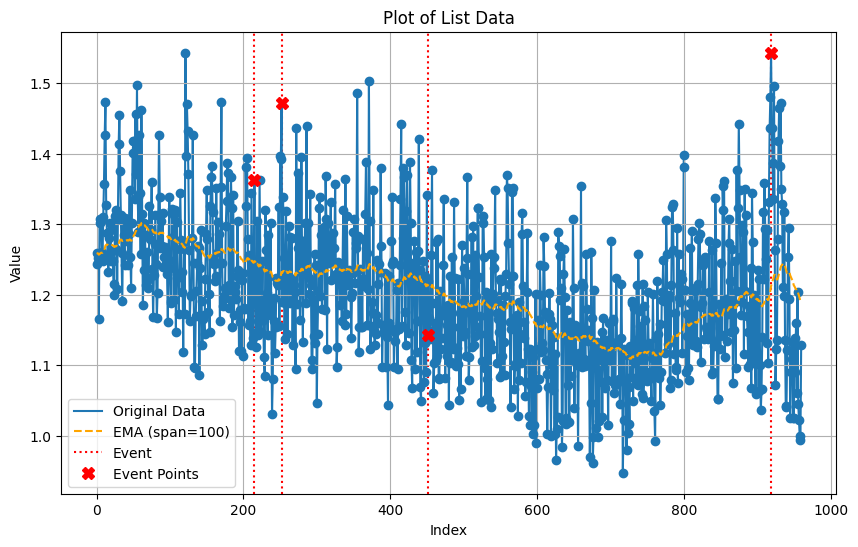

In [276]:
id1 = 1
id2 = 1
print(dd[id1]['correctness'])
print(dd[id1]['tag_indices'][id2])
plot_list(dd[id1]['values'][id2], ema_span=100, vline_indices=dd[id1]['tag_indices'][id2])

In [141]:
[len(dd[id1]['policy_responses'][id2].split('\n\n')[ii]) for ii in range(len(dd[id1]['policy_responses'][id2].split('\n\n')))]

[284, 86, 105, 239, 77, 292, 275, 239, 84, 142]

In [185]:
dd

Dataset({
    features: ['problem', 'solution', 'answer', 'subject', 'level', 'unique_id', 'policy_responses', 'finish_reason', 'correctness', 'values', 'tag_indices'],
    num_rows: 153
})

In [7]:
# --- 策略函数定义 ---

import numpy as np
from collections import Counter
from math_verify import parse
from collections import defaultdict


def select_by_majority(policy_responses, correctness_list, parse_function, **kwargs):
    if not policy_responses: return False, None
    parsed_items = []
    for i, resp_text in enumerate(policy_responses):
        try:
            parsed_ans = parse_function(resp_text)
            parsed_ans_hashable = parsed_ans[1]
            parsed_items.append({'parsed_answer': parsed_ans_hashable, 'original_index': i})
        except Exception as e:
            # print(f"解析 response 时发生错误: '{resp_text[:50]}...' - {e}")
            pass # 跳过无法解析的 response

    if not parsed_items: return False, None

    # 现在 item['parsed_answer'] 应该是可哈希的
    counts = Counter(item['parsed_answer'] for item in parsed_items)

    if not counts: return False, None # 理论上不会到这里

    top_count = counts.most_common(1)[0][1]
    candidate_values = {val for val, count in counts.items() if count == top_count}

    for item in parsed_items:
        if item['parsed_answer'] in candidate_values:
            return correctness_list[item['original_index']], item['original_index']
    return False, None # 理论上不应到达这里，如果 parsed_items 非空且 counts 非空

def weighted_majority_vote(policy_responses, correctness_list, values_for_each_response, tag_list, parse_function, mode, **kwargs):
    """
    Perform a weighted majority vote based on parsed responses and associated float values.
    
    Args:
        policy_responses: List of raw response strings
        correctness_list: List of correctness values (True/False) corresponding to responses
        value_list: List of float weights/values for each response
        parse_function: Function to parse raw responses into hashable formats
        **kwargs: Additional arguments for parse_function
        
    Returns:
        Tuple of (correctness, original_index) for the selected response
    """
    value_list = cal_values(policy_responses, correctness_list, values_for_each_response, tag_list, mode)
    if not policy_responses or len(policy_responses) != len(value_list) or len(policy_responses) != len(correctness_list):
        return False, None
    
    # Use defaultdict(float) for precise floating-point accumulation
    weighted_counts = defaultdict(float)
    # Also track all original indices for each answer to handle ties
    answer_indices = defaultdict(list)
    
    for i, (resp_text, value) in enumerate(zip(policy_responses, value_list)):
        try:
            parsed_ans = parse_function(resp_text)
            parsed_ans_hashable = parsed_ans[1]  # Assuming parse_function returns (original, hashable)
            weighted_counts[parsed_ans_hashable] += float(value)  # Ensure value is treated as float
            answer_indices[parsed_ans_hashable].append(i)
        except Exception as e:
            continue  # Skip unparseable responses

    if not weighted_counts:
        return False, None

    # Find the maximum weighted sum
    max_weight = max(weighted_counts.values())
    # Get all answers that achieved the max weight
    best_answers = [ans for ans, weight in weighted_counts.items() if weight == max_weight]

    # Among the best answers, select the one that appeared first in the original list
    # To do this, we find the minimum original index across all best answers
    min_index = None
    selected_answer = None
    
    for ans in best_answers:
        for idx in answer_indices[ans]:
            if min_index is None or idx < min_index:
                min_index = idx
                selected_answer = ans
    
    if min_index is not None:
        return correctness_list[min_index], min_index
    
    return False, None

def select_first_response(policy_responses, correctness_list, values_for_each_response, **kwargs):
    """
    选择第一个 policy_response。
    返回: (chosen_response_correct: bool, chosen_index: int or None)
          如果无法选择（例如 policy_responses 为空），返回 (False, None)
    """
    if not policy_responses:
        return False, None
    return correctness_list[0], 0

def cal_values(policy_responses, correctness_list, values_for_each_response, tag_list, mode='average'):
    if not policy_responses or len(policy_responses) != len(values_for_each_response):
        return False, None # 或者抛出异常，取决于你希望如何处理不一致的数据

    metric_values_for_responses = []
    for token_values_for_one_response, cur_tag_list in zip(values_for_each_response, tag_list):
        if token_values_for_one_response: # 确保 token_values 列表不为空
            if 'tag' in mode:
                token_values_for_one_response_tmp = [token_values_for_one_response[ii] for ii in range(len(token_values_for_one_response)) if ii+1 in cur_tag_list]
                if token_values_for_one_response_tmp == []:
                    token_values_for_one_response = [token_values_for_one_response[-1]]
                else:
                    token_values_for_one_response = token_values_for_one_response_tmp
            if mode == 'average':
                metric_values_for_responses.append(np.mean(token_values_for_one_response))
            elif mode == 'last':
                metric_values_for_responses.append(token_values_for_one_response[-1])
            elif mode == 'min':
                metric_values_for_responses.append(np.min(token_values_for_one_response))
            elif mode == 'max':
                metric_values_for_responses.append(np.max(token_values_for_one_response))
            elif mode == 'after_average':
                metric_values_for_responses.append(np.mean(token_values_for_one_response[len(token_values_for_one_response)//2:]))
            elif mode == 'before_average':
                metric_values_for_responses.append(np.mean(token_values_for_one_response[:len(token_values_for_one_response)//2]))
            elif mode == 'tag_average':
                metric_values_for_responses.append(np.mean(token_values_for_one_response))
            elif mode == 'tag_min':
                metric_values_for_responses.append(np.min(token_values_for_one_response))
            elif mode == 'tag_max':
                metric_values_for_responses.append(np.max(token_values_for_one_response))
            elif mode == 'tag_last':
                metric_values_for_responses.append(token_values_for_one_response[-1])
            else:
                print(f"警告: 未知的 mode '{mode}'，将使用 average。") # 或者抛出错误
                metric_values_for_responses.append(np.mean(token_values_for_one_response)) # 默认行为
        else:
            metric_values_for_responses.append(-float('inf')) # 如果某个 response 没有 values，给一个极小值
    
    return metric_values_for_responses

def select_by_value_metric(policy_responses, correctness_list, values_for_each_response, tag_list, mode='average'):
    """
    根据 values 的指定度量（'average' 或 'last'）选择 policy_response。
    返回: (chosen_response_correct: bool, chosen_index: int or None)
          如果无法选择，返回 (False, None)
    """
    metric_values_for_responses = cal_values(policy_responses, correctness_list, values_for_each_response, tag_list, mode)

    chosen_index = np.argmax(metric_values_for_responses)
    return correctness_list[chosen_index], chosen_index

# --- 主体计算逻辑 ---
total_data_points = 0
strategy_results = {} # 用于存储每种策略的正确数和可应用数

# 定义你想要测试的策略
# 每个策略是一个元组: (策略名称, 选择函数, {额外参数})
strategies_to_test = [
    ("Select First Response", select_first_response, {}),
    # ("Select by Value (Average)", select_by_value_metric, {"mode": "average"}),
    # ("Select by Value (After Average)", select_by_value_metric, {"mode": "after_average"}),
    # ("Select by Value (before_average)", select_by_value_metric, {"mode": "before_average"}),
    # ("Select by Value (Last)", select_by_value_metric, {"mode": "last"}),
    # ("Select by Value (Min)", select_by_value_metric, {"mode": "min"}),
    # ("Select by Value (Max)", select_by_value_metric, {"mode": "max"}),
    # ("Select by Value (Tag Last)", select_by_value_metric, {"mode": "tag_last"}),
    # ("Select by Value (Tag Min)", select_by_value_metric, {"mode": "tag_min"}),
    # ("Select by Value (Tag Max)", select_by_value_metric, {"mode": "tag_max"}),
    # ("Select by Value (Tag Avg)", select_by_value_metric, {"mode": "tag_average"}),
    # ("Select by Majority Value (Average)", weighted_majority_vote, {"mode": "average", "parse_function": parse}),
    # ("Select by Majority Value (Last)", weighted_majority_vote, {"mode": "last", "parse_function": parse}),
    # ("Select by Majority Value (Min)", weighted_majority_vote, {"mode": "min", "parse_function": parse}),
    ("Select by Most Frequent Answer", select_by_majority, {"parse_function": parse}),
]

# 初始化结果存储
for name, _, _ in strategies_to_test:
    strategy_results[name] = {"correct_count": 0, "applicable_count": 0}

# 遍历数据集
for i in tqdm(range(len(dd))):
    data_point = dd[i]
    total_data_points += 1

    policy_responses = data_point['policy_responses']
    correctness_list = data_point['correctness']
    values_for_each_response = data_point.get('values', [])
    tag_list = data_point.get('tag_indices', [])

    # # 校验数据点有效性
    # if not policy_responses or \
    #    len(policy_responses) != len(correctness_list) or \
    #    len(policy_responses) != len(values_for_each_response):
    #     # print(f"警告：数据点 {i} 列表长度不匹配或为空，跳过。")
    #     continue

    # 构造传递给选择函数的通用参数包
    # 注意：这里的 'values_for_each_response' 键名需要与 select_by_value_metric 函数的参数名匹配
    # 而 'parse_function' 键名需要与 select_by_most_frequent_answer 函数的参数名匹配
    base_args_for_selection = {
        "policy_responses": policy_responses,
        "correctness_list": correctness_list,
        "values_for_each_response": values_for_each_response, # 提供给 select_by_value_metric
        "tag_list": tag_list,
        # "parse_function" 会在下面与 specific_params 合并时被特定策略的参数覆盖
    }

    # 应用每种策略
    for strategy_name, selection_function, specific_params in strategies_to_test:
        # 合并通用参数和特定于策略的参数
        # specific_params 会覆盖 base_args_for_selection 中的同名键
        current_params = {**base_args_for_selection, **specific_params}

        is_correct, chosen_idx = selection_function(**current_params)

        if chosen_idx is not None: # 策略成功做出选择
            strategy_results[strategy_name]["applicable_count"] += 1
            if is_correct:
                strategy_results[strategy_name]["correct_count"] += 1

# 计算并打印结果
print(f"数据集总数: {total_data_points}")
for name, results in strategy_results.items():
    correct_count = results["correct_count"]
    applicable_count = results["applicable_count"]
    prob_overall = correct_count / total_data_points if total_data_points > 0 else 0
    prob_if_applicable = correct_count / applicable_count if applicable_count > 0 else 0

    # print(f"\n--- 策略: {name} ---")
    # print(f"  正确数量: {correct_count}")
    # print(f"  策略可应用次数: {applicable_count}")
    # print(f"  正确总体概率 (基于所有数据点): {prob_overall:.4f}")
    # print(f"  正确概率 (仅当策略可应用时): {prob_if_applicable:.4f}")
    print(f"\n--- 策略: {name}{prob_overall:.4f}")

100%|██████████| 468/468 [00:09<00:00, 48.90it/s]

数据集总数: 468

--- 策略: Select First Response0.7650

--- 策略: Select by Most Frequent Answer0.8013


In [ ]:
strategy_results

{'Select First Response': {'correct_count': 349, 'applicable_count': 500},
 'Select by Most Frequent Answer': {'correct_count': 394,
  'applicable_count': 500}}

In [11]:
import sys
sys.path.append('/mnt/workspace/_')
from utils import load_hf

In [13]:
dd = load_hf('/mnt/workspace/hf_models/datasets--hkust-nlp--SimpleRL-Zoo-Data/simplelr_qwen_level3to5/test.parquet', 'parquet')

加载数据集:   0%|          | 0/1 [00:00<?, ?文件/s]
Generating train split: 500 examples [00:00, 20878.19 examples/s]
加载数据集: 100%|██████████| 1/1 [00:00<00:00,  1.08文件/s]


In [14]:
dd['train'][0]

{'solution': 'A $90^\\circ$ rotation around the origin in the counter-clockwise direction corresponds to multiplication by $\\operatorname{cis} 90^\\circ = i.$\n\n[asy]\nunitsize(0.5 cm);\n\ndraw((-3,0)--(8,0));\ndraw((0,-1)--(0,8));\ndraw((0,0)--(7,2),dashed);\ndraw((0,0)--(-2,7),dashed);\n\ndot("$7 + 2i$", (7,2), E);\ndot("$-2 + 7i$", (-2,7), N);\n[/asy]\n\nThus, the image of $7 + 2i$ is $i(7 + 2i) = \\boxed{-2 + 7i}.$',
 'subject': 'Precalculus',
 'level': 2,
 'unique_id': 'test/precalculus/779.json',
 'data_source': 'simplelr_qwen',
 'prompt': [{'content': '<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\nA $90^\\circ$ rotation around the origin in the counter-clockwise direction is applied to $7 + 2i.$  What is the resulting complex number?\nPlease reason step by step, and put your final answer within \\boxed{{}}.<|im_end|>\n<|im_start|>assistant\n',
   'role': 'user'}],
 'ability': 'math',
 'reward_model': {'ground_truth': '-2 + 7i', 'style': 'rule'},